In [1]:
import joblib

X_train_resampled = joblib.load("X_train_resampled.pkl")
y_train_resampled = joblib.load("y_train_resampled.pkl")
X_test_processed = joblib.load("X_test_processed.pkl")
y_test = joblib.load("y_test.pkl")
feature_names = joblib.load("feature_names.pkl")

In [2]:
# ============================================
# BLOCK 1: Model Training Setup and Data Check
# ============================================

# ============================================
# 1. Import Required Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================
# 2. Verify Shapes of Training and Testing Data
# ============================================

print("=" * 60)
print("DATASET SHAPES")
print("=" * 60)

print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"y_test shape: {y_test.shape}")


# ============================================
# 3. Display Class Distribution
# ============================================

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print("\nClass Distribution in y_train_resampled:")
display(
    y_train_resampled.value_counts()
    .sort_index()
)

print("\nClass Distribution in y_test:")
display(
    y_test.value_counts()
    .sort_index()
)

DATASET SHAPES
X_train_resampled shape: (8262, 45)
y_train_resampled shape: (8262,)
X_test_processed shape: (1405, 45)
y_test shape: (1405,)

CLASS DISTRIBUTION

Class Distribution in y_train_resampled:


Churn
0    4131
1    4131
Name: count, dtype: int64


Class Distribution in y_test:


Churn
0    1033
1     372
Name: count, dtype: int64

In [3]:
# ============================================
# Logistic Regression Baseline Model
# ============================================

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ============================================
# Train the Model
# ============================================

logistic_model.fit(
    X_train_resampled,
    y_train_resampled
)


# ============================================
# Generate Predictions
# ============================================

y_pred_logistic = logistic_model.predict(
    X_test_processed
)


# ============================================
# Generate Churn Probability Predictions
# ============================================

# Probability of the positive class (Churn = 1)
y_proba_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

LOGISTIC REGRESSION MODEL EVALUATION
Accuracy : 0.7473
Precision: 0.5154
Recall   : 0.7634
F1-Score : 0.6154
ROC-AUC  : 0.8399

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1033
       Churn       0.52      0.76      0.62       372

    accuracy                           0.75      1405
   macro avg       0.71      0.75      0.71      1405
weighted avg       0.80      0.75      0.76      1405


CONFUSION MATRIX
[[766 267]
 [ 88 284]]


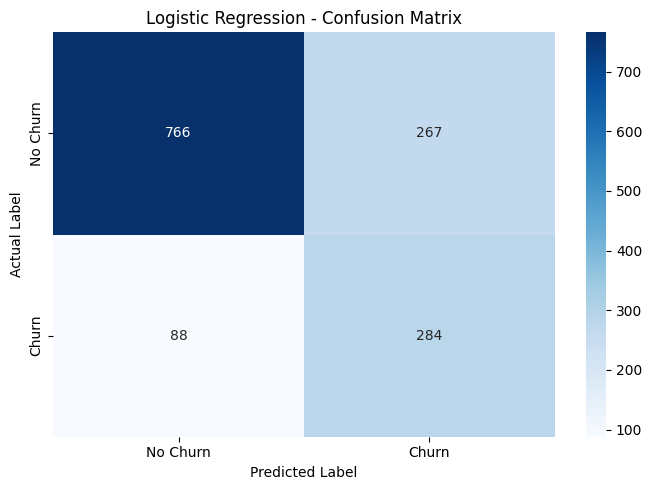

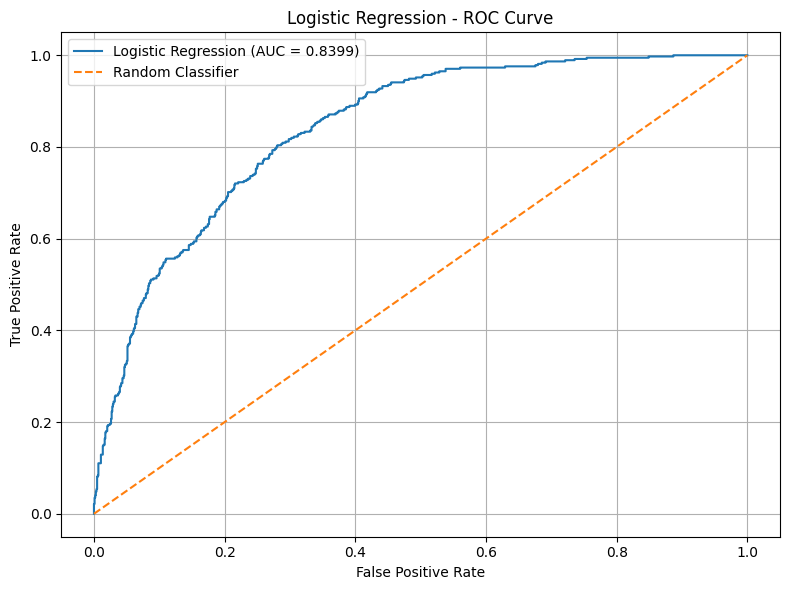

In [4]:
# ============================================
# Logistic Regression Model Evaluation
# ============================================

# ============================================
# 1. Calculate Evaluation Metrics
# ============================================

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    pos_label=1
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    pos_label=1
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    pos_label=1
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_proba_logistic
)


# ============================================
# 2. Print All Metrics Clearly
# ============================================

print("=" * 60)
print("LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1-Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")


# ============================================
# 3. Classification Report
# ============================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)


# ============================================
# 4. Calculate Confusion Matrix
# ============================================

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm_logistic)


# ============================================
# 5. Plot Confusion Matrix
# ============================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()


# ============================================
# 6. Plot ROC Curve
# ============================================

from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_proba_logistic,
    pos_label=1
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Logistic Regression - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [5]:
# ============================================
# Logistic Regression Results DataFrame
# ============================================

# Create a DataFrame containing model evaluation results
results_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_logistic],
    "Precision": [precision_logistic],
    "Recall": [recall_logistic],
    "F1-Score": [f1_logistic],
    "ROC-AUC": [roc_auc_logistic]
})


# ============================================
# Display Results Sorted by ROC-AUC
# ============================================

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.747331,0.515426,0.763441,0.615385,0.839898


In [6]:
# ============================================
# Import and Verify XGBoost
# ============================================

# Import XGBClassifier from XGBoost
from xgboost import XGBClassifier

# Import XGBoost to check the installed version
import xgboost as xgb


# ============================================
# Verify XGBoost Installation
# ============================================

print("XGBoost Version:")
print(xgb.__version__)

XGBoost Version:
3.2.0


In [7]:
# ============================================
# XGBoost Baseline Model
# ============================================

# Create the XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)


# ============================================
# Train the XGBoost Model
# ============================================

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)


# ============================================
# Generate Predictions
# ============================================

y_pred_xgb = xgb_model.predict(
    X_test_processed
)


# ============================================
# Generate Churn Probability Predictions
# ============================================

# Probability of the positive class (Churn = 1)
y_proba_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

XGBOOST MODEL EVALUATION
Accuracy : 0.7843
Precision: 0.5848
Recall   : 0.6398
F1-Score : 0.6110
ROC-AUC  : 0.8398

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.85      1033
       Churn       0.58      0.64      0.61       372

    accuracy                           0.78      1405
   macro avg       0.73      0.74      0.73      1405
weighted avg       0.79      0.78      0.79      1405


CONFUSION MATRIX
[[864 169]
 [134 238]]


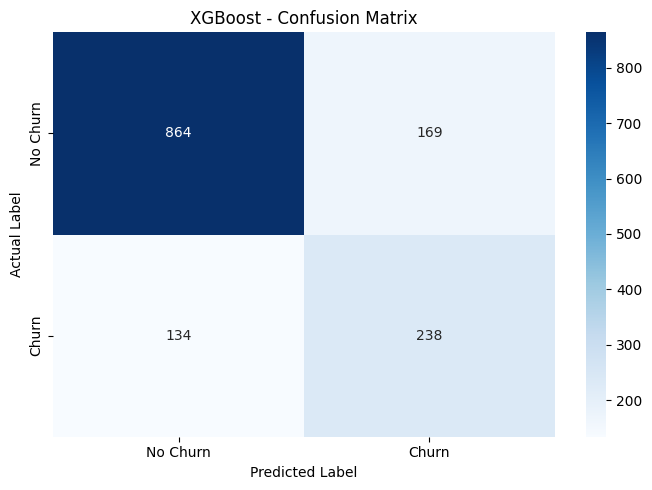

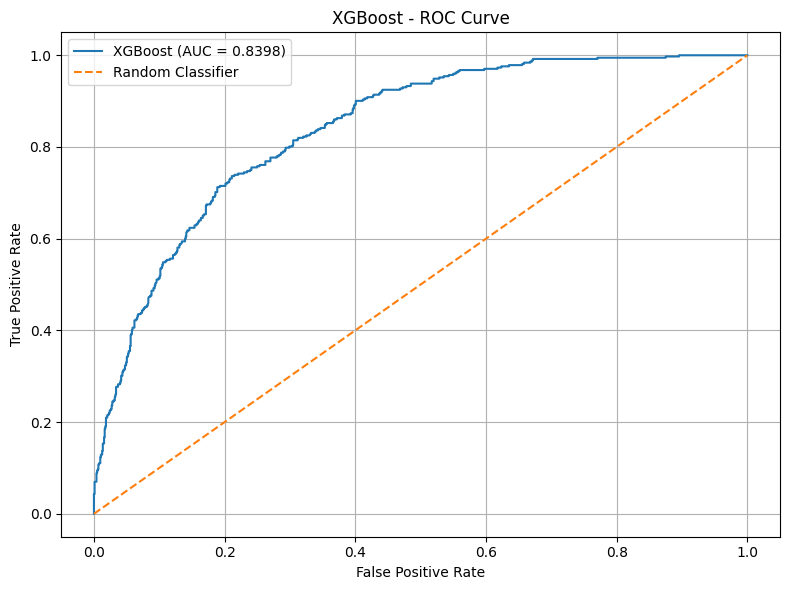

In [8]:
# ============================================
# XGBoost Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)


# ============================================
# 1. Calculate Evaluation Metrics
# ============================================

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)


# ============================================
# 2. Print All Metrics Clearly
# ============================================

print("=" * 60)
print("XGBOOST MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")


# ============================================
# 3. Classification Report
# ============================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Churn", "Churn"]
    )
)


# ============================================
# 4. Calculate Confusion Matrix
# ============================================

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm_xgb)


# ============================================
# 5. Plot Confusion Matrix
# ============================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()


# ============================================
# 6. Plot ROC Curve
# ============================================

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(
    y_test,
    y_proba_xgb,
    pos_label=1
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("XGBoost - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# Add XGBoost Results to Results DataFrame
# ============================================

# Calculate XGBoost evaluation metrics
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    pos_label=1
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)


# ============================================
# Create XGBoost Results Row
# ============================================

xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_xgb],
    "Precision": [precision_xgb],
    "Recall": [recall_xgb],
    "F1-Score": [f1_xgb],
    "ROC-AUC": [roc_auc_xgb]
})


# ============================================
# Append XGBoost Results
# ============================================

results_df = pd.concat(
    [results_df, xgb_results],
    ignore_index=True
)


# ============================================
# Sort Results by ROC-AUC
# ============================================

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


# ============================================
# Display Complete Model Comparison
# ============================================

print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)

display(results_df)

MODEL COMPARISON RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.747331,0.515426,0.763441,0.615385,0.839898
1,XGBoost,0.784342,0.584767,0.639785,0.611040,0.839829


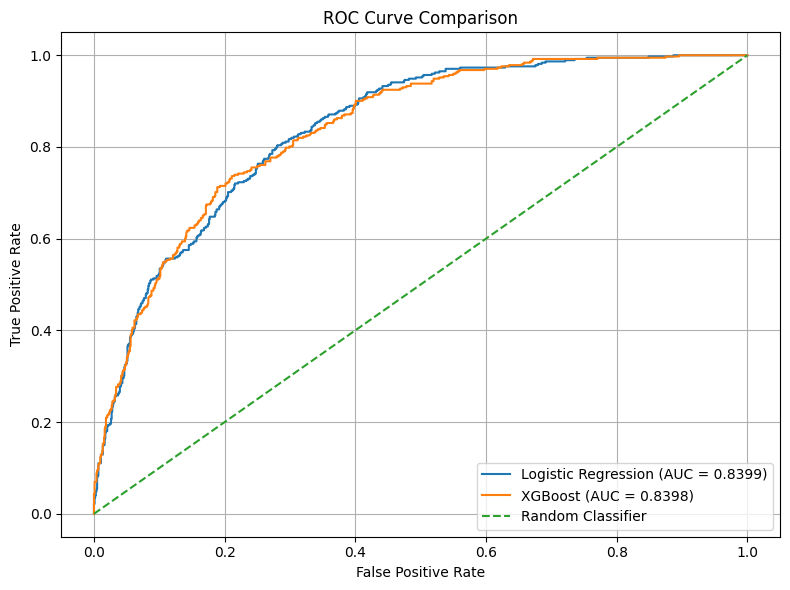

In [10]:
# ============================================
# ROC Curve Comparison: Logistic Regression vs XGBoost
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score

# ============================================
# 1. Calculate ROC Curve for Logistic Regression
# ============================================

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_proba_logistic,
    pos_label=1
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_proba_logistic
)


# ============================================
# 2. Calculate ROC Curve for XGBoost
# ============================================

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_proba_xgb,
    pos_label=1
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)


# ============================================
# 3. Plot ROC Curves
# ============================================

plt.figure(figsize=(8, 6))

# Logistic Regression ROC Curve
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.4f})"
)

# XGBoost ROC Curve
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.4f})"
)

# Random Classifier Reference Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


# ============================================
# 4. Add Plot Labels and Formatting
# ============================================

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# Import Libraries for XGBoost Hyperparameter Tuning
# ============================================

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [12]:
# ============================================
# Stratified K-Fold Cross-Validation Strategy
# ============================================

from sklearn.model_selection import StratifiedKFold


# ============================================
# Create Cross-Validation Strategy
# ============================================

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================
# Display Cross-Validation Configuration
# ============================================

print("Cross-Validation Configuration:")
print(f"Number of Splits : {cv_strategy.n_splits}")
print(f"Shuffle           : {cv_strategy.shuffle}")
print(f"Random State      : {cv_strategy.random_state}")

Cross-Validation Configuration:
Number of Splits : 5
Shuffle           : True
Random State      : 42


In [13]:
# ============================================
# XGBoost Hyperparameter Grid
# ============================================

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3]
}

In [14]:
# ============================================
# Base XGBoost Classifier for GridSearchCV
# ============================================

xgb_tuning_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [15]:
# ============================================
# XGBoost Hyperparameter Tuning with GridSearchCV
# ============================================

from sklearn.model_selection import GridSearchCV


# ============================================
# Create GridSearchCV
# ============================================

grid_search_xgb = GridSearchCV(
    estimator=xgb_tuning_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


# ============================================
# Fit GridSearchCV on Training Data
# ============================================

grid_search_xgb.fit(
    X_train_resampled,
    y_train_resampled
)


# ============================================
# Display Best Parameters
# ============================================

print("\n" + "=" * 60)
print("BEST XGBOOST HYPERPARAMETERS")
print("=" * 60)

print(grid_search_xgb.best_params_)


# ============================================
# Display Best Cross-Validation ROC-AUC Score
# ============================================

print("\n" + "=" * 60)
print("BEST CROSS-VALIDATION ROC-AUC SCORE")
print("=" * 60)

print(f"{grid_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

BEST XGBOOST HYPERPARAMETERS
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}

BEST CROSS-VALIDATION ROC-AUC SCORE
0.9372


In [16]:
# ============================================
# Extract and Inspect Best XGBoost Model
# ============================================

# 1. Extract the best estimator
best_xgb_model = grid_search_xgb.best_estimator_


# 2. Extract the best hyperparameters
best_xgb_params = grid_search_xgb.best_params_


# 3. Extract the best cross-validation ROC-AUC score
best_cv_roc_auc = grid_search_xgb.best_score_


# ============================================
# 4. Print Best Parameters
# ============================================

print("=" * 60)
print("BEST XGBOOST PARAMETERS")
print("=" * 60)

print(best_xgb_params)


# ============================================
# 5. Print Best Cross-Validation ROC-AUC
# ============================================

print("\n" + "=" * 60)
print("BEST CROSS-VALIDATION ROC-AUC")
print("=" * 60)

print(f"{best_cv_roc_auc:.4f}")


# ============================================
# 6. Print Best Model Configuration
# ============================================

print("\n" + "=" * 60)
print("BEST XGBOOST MODEL CONFIGURATION")
print("=" * 60)

print(best_xgb_model)

BEST XGBOOST PARAMETERS
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}

BEST CROSS-VALIDATION ROC-AUC
0.9372

BEST XGBOOST MODEL CONFIGURATION
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [17]:
# ============================================
# Generate Predictions Using Tuned XGBoost
# ============================================

# Generate class predictions
y_pred_xgb_tuned = best_xgb_model.predict(
    X_test_processed
)


# Generate probability predictions
# Extract probability of the positive class (Churn = 1)
y_proba_xgb_tuned = best_xgb_model.predict_proba(
    X_test_processed
)[:, 1]

TUNED XGBOOST MODEL EVALUATION
Accuracy : 0.7851
Precision: 0.5951
Recall   : 0.5887
F1-Score : 0.5919
ROC-AUC  : 0.8361

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.85      0.86      0.85      1033
       Churn       0.60      0.59      0.59       372

    accuracy                           0.79      1405
   macro avg       0.72      0.72      0.72      1405
weighted avg       0.78      0.79      0.78      1405


CONFUSION MATRIX
[[884 149]
 [153 219]]


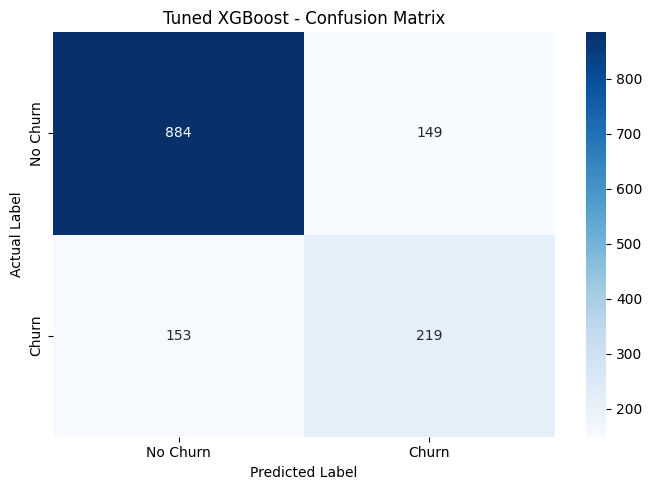

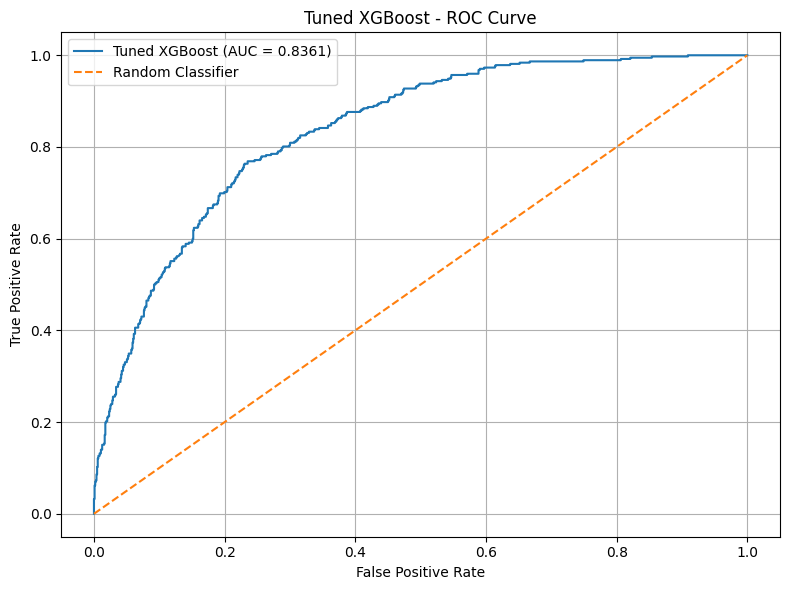

In [18]:
# ============================================
# Tuned XGBoost Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)


# ============================================
# 1. Calculate Evaluation Metrics
# ============================================

accuracy_xgb_tuned = accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

precision_xgb_tuned = precision_score(
    y_test,
    y_pred_xgb_tuned,
    pos_label=1
)

recall_xgb_tuned = recall_score(
    y_test,
    y_pred_xgb_tuned,
    pos_label=1
)

f1_xgb_tuned = f1_score(
    y_test,
    y_pred_xgb_tuned,
    pos_label=1
)

roc_auc_xgb_tuned = roc_auc_score(
    y_test,
    y_proba_xgb_tuned
)


# ============================================
# 2. Print All Metrics Clearly
# ============================================

print("=" * 60)
print("TUNED XGBOOST MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy : {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall   : {recall_xgb_tuned:.4f}")
print(f"F1-Score : {f1_xgb_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb_tuned:.4f}")


# ============================================
# 3. Classification Report
# ============================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_xgb_tuned,
        target_names=["No Churn", "Churn"]
    )
)


# ============================================
# 4. Calculate Confusion Matrix
# ============================================

cm_xgb_tuned = confusion_matrix(
    y_test,
    y_pred_xgb_tuned
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm_xgb_tuned)


# ============================================
# 5. Plot Confusion Matrix
# ============================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()


# ============================================
# 6. Calculate ROC Curve
# ============================================

fpr_xgb_tuned, tpr_xgb_tuned, thresholds_xgb_tuned = roc_curve(
    y_test,
    y_proba_xgb_tuned,
    pos_label=1
)


# ============================================
# 7. Plot ROC Curve
# ============================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_xgb_tuned,
    tpr_xgb_tuned,
    label=f"Tuned XGBoost (AUC = {roc_auc_xgb_tuned:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Tuned XGBoost - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [19]:
# ============================================
# Baseline vs Tuned XGBoost Comparison
# ============================================

# Calculate Baseline XGBoost metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, pos_label=1)
recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
f1_xgb = f1_score(y_test, y_pred_xgb, pos_label=1)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)


# Calculate Tuned XGBoost metrics
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned, pos_label=1)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned, pos_label=1)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned, pos_label=1)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_proba_xgb_tuned)


# ============================================
# Create XGBoost Comparison DataFrame
# ============================================

xgb_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_xgb,
        accuracy_xgb_tuned
    ],
    "Precision": [
        precision_xgb,
        precision_xgb_tuned
    ],
    "Recall": [
        recall_xgb,
        recall_xgb_tuned
    ],
    "F1-Score": [
        f1_xgb,
        f1_xgb_tuned
    ],
    "ROC-AUC": [
        roc_auc_xgb,
        roc_auc_xgb_tuned
    ]
})


# ============================================
# Sort by ROC-AUC in Descending Order
# ============================================

xgb_comparison_df = xgb_comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


# ============================================
# Display Comparison
# ============================================

display(xgb_comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline XGBoost,0.784342,0.584767,0.639785,0.611040,0.839829
1,Tuned XGBoost,0.785053,0.595109,0.588710,0.591892,0.836131


In [20]:
# ============================================
# Final Model Comparison
# ============================================

# Select the required columns from Logistic Regression results
logistic_results = results_df[
    results_df["Model"] == "Logistic Regression"
][[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]]


# Select the required columns from XGBoost comparison results
xgb_results = xgb_comparison_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]]


# ============================================
# Combine Results from All Three Models
# ============================================

final_model_comparison = pd.concat(
    [logistic_results, xgb_results],
    ignore_index=True
)


# ============================================
# Sort by ROC-AUC in Descending Order
# ============================================

final_model_comparison = final_model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


# ============================================
# Display Final Model Comparison
# ============================================

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(final_model_comparison)


# ============================================
# Identify Model with Highest Test ROC-AUC
# ============================================

best_model = final_model_comparison.iloc[0]["Model"]
best_test_roc_auc = final_model_comparison.iloc[0]["ROC-AUC"]

print("\n" + "=" * 70)
print("BEST MODEL BASED ON TEST ROC-AUC")
print("=" * 70)

print(f"Best Model: {best_model}")
print(f"Highest Test ROC-AUC: {best_test_roc_auc:.4f}")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.747331,0.515426,0.763441,0.615385,0.839898
1,Baseline XGBoost,0.784342,0.584767,0.639785,0.611040,0.839829
2,Tuned XGBoost,0.785053,0.595109,0.588710,0.591892,0.836131



BEST MODEL BASED ON TEST ROC-AUC
Best Model: Logistic Regression
Highest Test ROC-AUC: 0.8399


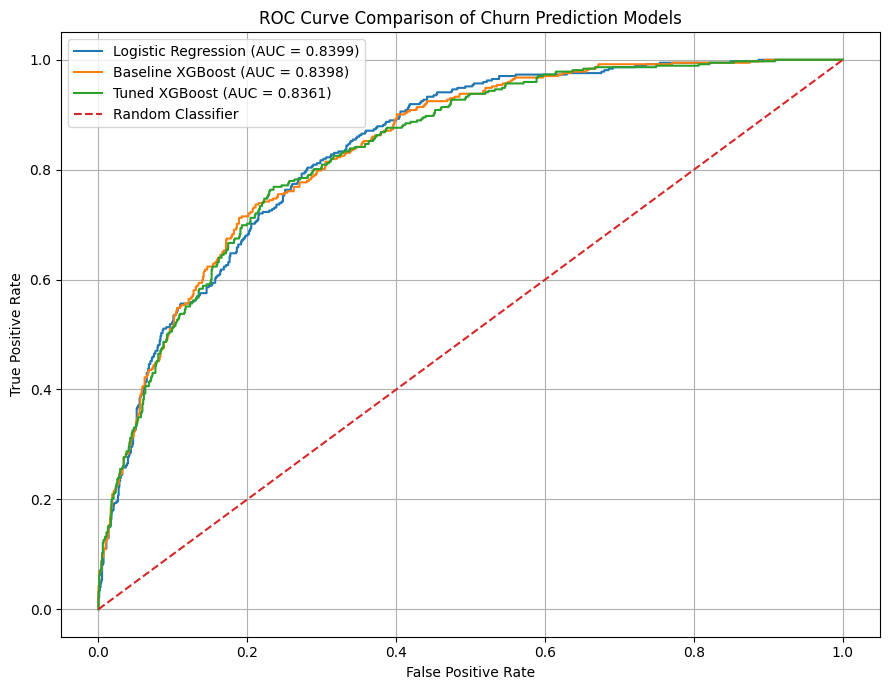

In [21]:
# ============================================
# ROC Curve Comparison of Churn Prediction Models
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score


# ============================================
# 1. Logistic Regression ROC Curve and AUC
# ============================================

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_proba_logistic,
    pos_label=1
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_proba_logistic
)


# ============================================
# 2. Baseline XGBoost ROC Curve and AUC
# ============================================

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_proba_xgb,
    pos_label=1
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)


# ============================================
# 3. Tuned XGBoost ROC Curve and AUC
# ============================================

fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(
    y_test,
    y_proba_xgb_tuned,
    pos_label=1
)

roc_auc_xgb_tuned = roc_auc_score(
    y_test,
    y_proba_xgb_tuned
)


# ============================================
# 4. Plot All ROC Curves
# ============================================

plt.figure(figsize=(9, 7))

# Logistic Regression
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.4f})"
)

# Baseline XGBoost
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"Baseline XGBoost (AUC = {roc_auc_xgb:.4f})"
)

# Tuned XGBoost
plt.plot(
    fpr_xgb_tuned,
    tpr_xgb_tuned,
    label=f"Tuned XGBoost (AUC = {roc_auc_xgb_tuned:.4f})"
)


# ============================================
# 5. Random Classifier Reference Line
# ============================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


# ============================================
# 6. Add Plot Labels and Formatting
# ============================================

plt.title("ROC Curve Comparison of Churn Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# Save Final Tuned XGBoost Model
# ============================================

import os
import joblib


# ============================================
# Create Models Directory
# ============================================

os.makedirs("models", exist_ok=True)


# ============================================
# Save the Final Tuned XGBoost Model
# ============================================

model_path = "models/final_xgboost_churn_model.pkl"

joblib.dump(
    best_xgb_model,
    model_path
)


# ============================================
# Verify Model File Exists
# ============================================

if os.path.exists(model_path):
    print(f"Model saved successfully at: {model_path}")
    print("File exists: True")
else:
    print("Error: Model file was not saved.")

Model saved successfully at: models/final_xgboost_churn_model.pkl
File exists: True


In [24]:
# ============================================
# SAVE ARTIFACTS FOR SHAP
# ============================================

import os
import joblib

# Create models directory
os.makedirs("models", exist_ok=True)

# Save final tuned XGBoost model
joblib.dump(
    best_xgb_model,
    "models/final_xgboost_churn_model.pkl"
)

# Save processed test data
joblib.dump(
    X_test_processed,
    "models/X_test_processed.pkl"
)

# Save test target
joblib.dump(
    y_test,
    "models/y_test.pkl"
)

# Save feature names
joblib.dump(
    feature_names,
    "models/feature_names.pkl"
)

print("All required SHAP artifacts saved successfully!")

All required SHAP artifacts saved successfully!
